In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for nice visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
def load_insurance_data(file_path):
    df = pd.read_csv(file_path)
    # Ensure transaction months are treated as datetimes
    if 'TransactionMonth' in df.columns:
        df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])
    return df

# Load the dataset from your structure
df = load_insurance_data("../data/raw/insurance_data.csv")

# Display the first 5 rows and shape
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (10000, 23)


,UnderwrittenCoverID,PolicyID,TransactionMonth,Gender,MaritalStatus,Citizenship,Province,PostalCode,VehicleType,Make,...,SumInsured,CoverType,ExcessSelected,CalculatedPremiumPerTerm,AlarmImmobiliser,TrackingDevice,TotalPremium,TotalClaims,LossRatio,Margin
0,1,POL00000001,2014-05-14,Male,Married,South African,Free State,7500,Hatchback,Volkswagen,...,250000,Third Party Fire & Theft,3000,9546.657556,1,1,8978.63,0.0,0.0,8978.63
1,2,POL00000002,2015-04-12,Male,Widowed,South African,Northern Cape,9301,Hatchback,Volkswagen,...,200000,Third Party,3000,9823.642620,1,0,8399.21,0.0,0.0,8399.21
2,3,POL00000003,2014-10-29,Male,Married,South African,Mpumalanga,9301,Coupe,Nissan,...,150000,Third Party,2000,14033.174613,1,0,11998.36,0.0,0.0,11998.36
3,4,POL00000004,2014-05-18,Female,Married,South African,Western Cape,6001,Bakkie,Volkswagen,...,350000,Comprehensive,2000,2313.829512,0,0,2313.83,0.0,0.0,2313.83
4,5,POL00000005,2014-04-13,Female,Single,South African,KwaZulu-Natal,6001,Coupe,Toyota,...,300000,Comprehensive,5000,8224.817696,1,0,7032.22,0.0,0.0,7032.22


In [5]:
# Calculate core insurance metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

# Update this list based on what print(df.columns.tolist()) showed you!
available_cols = ['TotalPremium', 'TotalClaims', 'LossRatio', 'Margin', 'CustomValueEstimate']

# This safely filters only the columns that actually exist so it won't crash
existing_cols = [col for col in available_cols if col in df.columns]
df[existing_cols].describe()

,TotalPremium,TotalClaims,LossRatio,Margin
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,8332.078487,4777.984068,0.762354,3554.094419
std,3812.459687,13903.744277,2.723521,14417.100542
min,1633.900000,0.000000,0.000000,-163299.410000
25%,5064.642500,0.000000,0.000000,3226.505000
50%,8240.960000,0.000000,0.000000,6876.055000
75%,11435.822500,0.000000,0.000000,10717.680000
max,17993.390000,174939.680000,54.957682,17993.390000


Overall Portfolio Loss Ratio: 0.5734 (57.34%)


C:\Users\abbadal\AppData\Local\Temp\ipykernel_31540\227092214.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=province_lr.values, y=province_lr.index, palette="viridis")


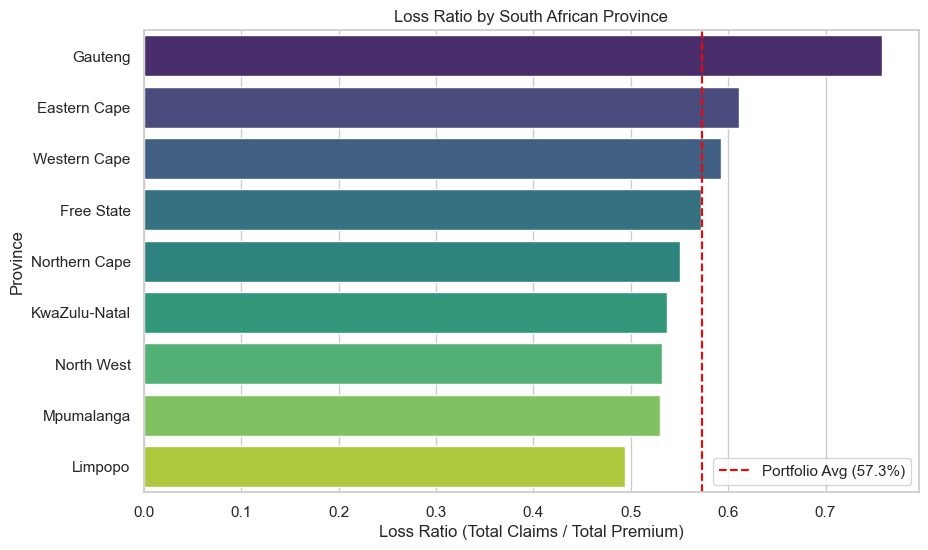

In [6]:
# 1. Overall Portfolio Loss Ratio
overall_lr = df['TotalClaims'].sum() / df['TotalPremium'].sum()
print(f"Overall Portfolio Loss Ratio: {overall_lr:.4f} ({overall_lr * 100:.2f}%)")

# 2. Loss Ratio by Province
province_lr = df.groupby('Province').apply(lambda x: x['TotalClaims'].sum() / x['TotalPremium'].sum()).sort_values(ascending=False)

# Plotting
sns.barplot(x=province_lr.values, y=province_lr.index, palette="viridis")
plt.title("Loss Ratio by South African Province")
plt.xlabel("Loss Ratio (Total Claims / Total Premium)")
plt.ylabel("Province")
plt.axvline(overall_lr, color='red', linestyle='--', label=f'Portfolio Avg ({overall_lr*100:.1f}%)')
plt.legend()
plt.show()

In [7]:
gender_lr = df.groupby('Gender').apply(lambda x: x['TotalClaims'].sum() / x['TotalPremium'].sum())
print("\n--- Loss Ratio by Gender ---")
print(gender_lr)

vehicle_lr = df.groupby('VehicleType').apply(lambda x: x['TotalClaims'].sum() / x['TotalPremium'].sum()).sort_values(ascending=False).head(10)
print("\n--- Top 10 High-Risk Vehicle Types ---")
print(vehicle_lr)


--- Loss Ratio by Gender ---
Gender
Female    0.566945
Male      0.580520
dtype: float64

--- Top 10 High-Risk Vehicle Types ---
VehicleType
SUV          0.620633
Coupe        0.615461
Bakkie       0.590358
Hatchback    0.556063
Sedan        0.483172
dtype: float64


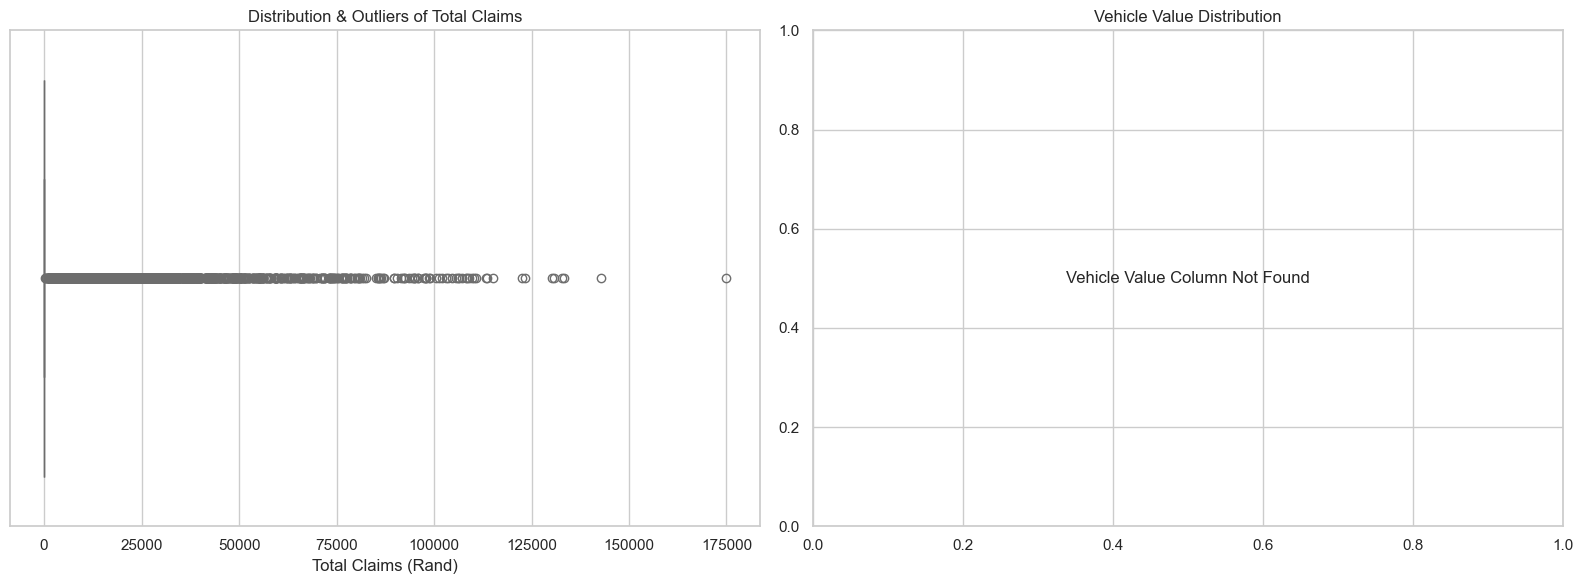

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Claims distribution boxplot
sns.boxplot(ax=axes[0], data=df, x='TotalClaims', color='salmon')
axes[0].set_title("Distribution & Outliers of Total Claims")
axes[0].set_xlabel("Total Claims (Rand)")

# 2. Custom Value Estimate boxplot (with fallback check)
# We find a column that contains 'Value' or 'Estimate' if the exact name differs
possible_value_cols = [col for col in df.columns if 'Value' in col or 'Estimate' in col or 'Mmcode' in col]

if 'CustomValueEstimate' in df.columns:
    value_col = 'CustomValueEstimate'
elif possible_value_cols:
    value_col = possible_value_cols[0]  # Grab the closest matching column found
else:
    value_col = None

if value_col:
    sns.boxplot(ax=axes[1], data=df, x=value_col, color='skyblue')
    axes[1].set_title(f"Distribution of {value_col}")
    axes[1].set_xlabel(value_col)
    print(f"Plotting vehicle values using column: '{value_col}'")
else:
    axes[1].text(0.5, 0.5, 'Vehicle Value Column Not Found', ha='center', va='center')
    axes[1].set_title("Vehicle Value Distribution")
    print("Warning: Could not find a vehicle value column. Available columns are:", df.columns.tolist())

plt.tight_layout()
plt.show()

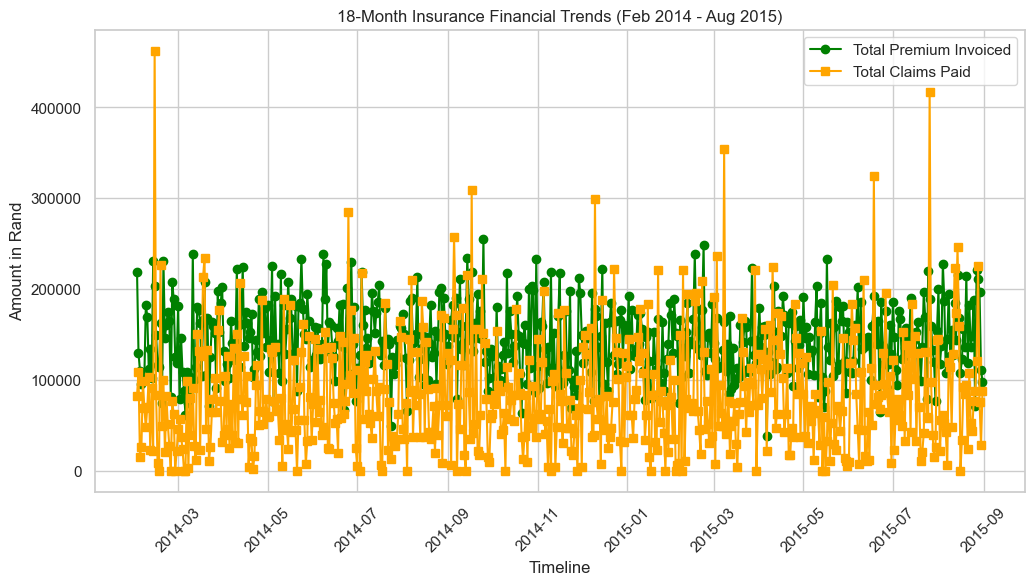

--- Top 5 Costliest Car Makes (Average Claim Amount) ---
Make
BMW         5396.331625
Ford        5216.087957
Mercedes    5005.258927
Honda       4691.997145
Hyundai     4649.340717
Name: TotalClaims, dtype: float64

--- Top 5 Safest/Cheapest Car Makes ---
Make
Honda         4691.997145
Hyundai       4649.340717
Volkswagen    4565.056398
Toyota        4415.305616
Nissan        4257.774358
Name: TotalClaims, dtype: float64


In [10]:
# Monthly trend of total premiums and total claims
temporal_df = df.groupby('TransactionMonth')[['TotalPremium', 'TotalClaims']].sum()

plt.figure(figsize=(12, 6))
plt.plot(temporal_df.index, temporal_df['TotalPremium'], label='Total Premium Invoiced', marker='o', color='green')
plt.plot(temporal_df.index, temporal_df['TotalClaims'], label='Total Claims Paid', marker='s', color='orange')
plt.title("18-Month Insurance Financial Trends (Feb 2014 - Aug 2015)")
plt.xlabel("Timeline")
plt.ylabel("Amount in Rand")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# High/Low risk vehicle manufacturers
make_claims = df.groupby('Make')['TotalClaims'].mean().sort_values(ascending=False)
print("--- Top 5 Costliest Car Makes (Average Claim Amount) ---")
print(make_claims.head(5))
print("\n--- Top 5 Safest/Cheapest Car Makes ---")
print(make_claims.tail(5))